# Tutorial 4 — Study & Investigation Templates

A **template** is a document that is *not ground*: it has open **sites** — the holes
bigraph-schema fills. This tutorial shows the framework's central move:

> a **study** and an **investigation** are *the same kind of thing* as a composite —
> a bigraph document. Filling their open sites turns them into a runnable `Composite`.
> No new execution engine, no scheduler, no special-casing: one object, one operation
> (*fill*), one law (*groundness*).

By the end you will be able to:

1. build a **study template** — a fixed analysis network with the *model* left as a hole,
2. **fill** the hole and get a `Composite` that constructs and runs,
3. see the hole is **face-sorted** — only a model with the right interface fits,
4. build an **investigation template** — one hole per member study,
5. express **gating as filling** — a filled member runs, an unfilled one is pruned,
6. save/load templates as **`*.template.yaml`** files.

The API lives in [`process_bigraph.templates`](https://github.com/vivarium-collective/process-bigraph/blob/main/process_bigraph/templates.py).
For the wider picture (higher-order DAG, content-addressed artifacts, the `git:` protocol)
see [`doc/architecture.md`](https://github.com/vivarium-collective/process-bigraph/blob/main/doc/architecture.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from process_bigraph import allocate_core
from process_bigraph.composite import Composite, Step
from process_bigraph.templates import (
    open_sites,            # the paths of every hole still open
    required_open_sites,   # holes with no default — the ones that block a build
    is_ground_document,    # True when nothing is left to fill (the runnable predicate)
    fill_template,         # fill some sites; unbound sites stay open (incremental)
    template_document,     # fill a STUDY and render the doc a Composite consumes
    investigation_document,# fill an INVESTIGATION, pruning members left open
)

## 1. The ingredients: a face, a flush step, a model

A study here is deliberately tiny so the machinery is visible:

- **`MODEL_FACE`** — the *interface* the model must present: it reads and writes a
  `level`. This is what the site is *sorted* by; it is the contract a filler must meet.
- **`ReportCard`** — a fixed downstream `Step` (a "flush"): it turns the model's final
  `level` into a `pass`/`fail` verdict. This part of the study is **not** a hole — every
  study built from this template shares the same analysis network.
- **`IncreaseProcess`** — a stock example process (already registered by `allocate_core`)
  that grows `level` by a fraction `rate` each step (`level *= 1 + rate`). This is the
  *model* we will drop into the hole; `rate > 0` grows the level, `rate < 0` decays it.

In [2]:
# The interface the model site is sorted by: reads a level, writes a level.
MODEL_FACE = {'_type': 'link', '_inputs': {'level': 'float'}, '_outputs': {'level': 'float'}}


class ReportCard(Step):
    """A study's fixed flush: final level -> pass/fail verdict."""
    config_schema = {'threshold': 'float'}
    def inputs(self):  return {'level': 'float'}
    def outputs(self): return {'verdict': 'string'}
    def update(self, state):
        return {'verdict': 'pass' if state['level'] >= self.config['threshold'] else 'fail'}


core = allocate_core()
core.register_link('ReportCard', ReportCard)   # make ReportCard resolvable as local:ReportCard
print('core ready')

module `pbg_emitters.parquet_emitter` not found during dynamic import
core ready


## 2. A study template: fixed network, model as a hole

`study_region` returns an ordinary document — two stores (`level`, `verdict`), a fixed
`report` step wired to them, and a **`model` site**. The site is written *in place*
with `_type: 'site'` and `_sort: MODEL_FACE`. That single line is the whole difference
between a template and a plain composite: a hole, sorted by an interface.

`model(rate)` is a conforming filler — an `IncreaseProcess` presenting exactly the
`level -> level` face the site demands.

In [3]:
def study_region(threshold=2.0):
    """A study: fixed report step + stores, with the MODEL left as a site (a hole)."""
    return {
        'level': 1.0,
        'verdict': 'string',
        'model': {'_type': 'site', '_sort': MODEL_FACE},          # <- the hole
        'report': {
            '_type': 'step', 'address': 'local:ReportCard',
            'config': {'threshold': threshold},
            'inputs':  {'level': ['level']},
            'outputs': {'verdict': ['verdict']}},
    }


def model(rate=0.5):
    """A conforming filler: grows level by a fraction `rate` each step."""
    return core.access({
        '_type': 'process', 'address': 'local:IncreaseProcess',
        'config': {'rate': rate}, 'interval': 1.0,
        'inputs':  {'level': ['level']},
        'outputs': {'level': ['level']}})


template = core.access({'study': study_region(threshold=2.0)})

print('open sites: ', open_sites(template))
print('required:   ', required_open_sites(template))
print('is ground?  ', is_ground_document(template), '  <- not runnable yet: a hole is open')

open sites:  [('study', 'model')]
required:    [('study', 'model')]
is ground?   False   <- not runnable yet: a hole is open


The template has exactly one open, required site: `('study', 'model')`. `is_ground_document`
is `False`, so the framework knows it cannot run yet — and it will *say so by name* rather
than fail obscurely at construction.

## 3. Fill the hole → a runnable Composite

`template_document(core, template, bindings)` fills the sites named in `bindings` and
renders the document a `Composite` consumes. Bindings are keyed by the site's path,
joined with `/` — here `'study/model'`. Once the required site is filled the document is
ground, and it constructs and runs like any composite. **No code changed** — we only
dropped a value into a hole.

In [4]:
document = template_document(core, template, {'study/model': model(rate=0.5)})

sim = Composite({'state': document}, core=core)
print('process paths:', list(sim.process_paths))   # the model we dropped in
print('step paths:   ', list(sim.step_paths))       # the fixed report card

sim.run(4.0)
print(f"final level: {sim.state['study']['level']:.3f}")
print(f"verdict:     {sim.state['study']['verdict']}")

process paths: [('study', 'model')]
step paths:    [('study', 'report')]
final level: 5.062
verdict:     pass


### The template is reusable: one network, any conforming model

Because the site accepts *any* filler meeting `MODEL_FACE`, the same template scores a
whole family of models. Below we fill it with a sweep of `rate` values and read off each
study's verdict. A large enough positive `rate` grows the level past the threshold within
the run (**pass**); a small or negative `rate` leaves it short (**fail**). This is the
study as a *reusable measuring instrument*.

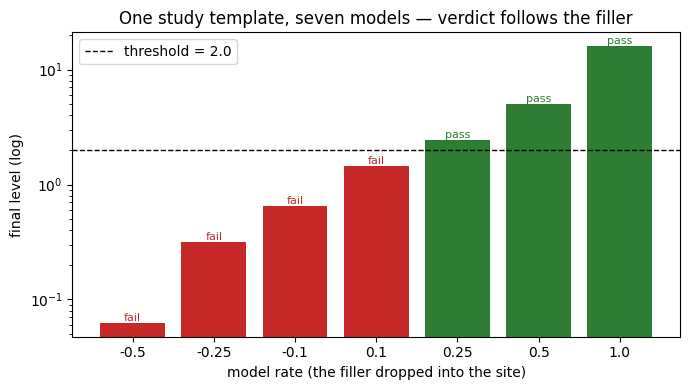

In [5]:
rates = [-0.5, -0.25, -0.1, 0.1, 0.25, 0.5, 1.0]
threshold = 2.0
finals, verdicts = [], []
for r in rates:
    tmpl = core.access({'study': study_region(threshold=threshold)})
    doc = template_document(core, tmpl, {'study/model': model(rate=r)})
    s = Composite({'state': doc}, core=core)
    s.run(4.0)
    finals.append(s.state['study']['level'])
    verdicts.append(s.state['study']['verdict'])

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2e7d32' if v == 'pass' else '#c62828' for v in verdicts]
ax.bar([str(r) for r in rates], finals, color=colors)
ax.axhline(threshold, ls='--', color='k', lw=1, label=f'threshold = {threshold}')
ax.set_yscale('log')
ax.set_xlabel('model rate (the filler dropped into the site)')
ax.set_ylabel('final level (log)')
ax.set_title('One study template, seven models — verdict follows the filler')
ax.legend()
for x, (f, v) in enumerate(zip(finals, verdicts)):
    ax.text(x, f, v, ha='center', va='bottom', fontsize=8, color=colors[x])
plt.tight_layout(); plt.show()

## 4. The hole is *face-sorted*: only a conforming model fits

A site is not a blank — it carries an interface (`_sort`). Filling it with something of
the wrong shape is refused **before** anything is constructed, and the error names the
site. Here a link that outputs `mass` instead of `level` does not meet `MODEL_FACE`:

In [6]:
nonconforming = core.access({
    '_type': 'link', '_inputs': {'level': 'float'}, '_outputs': {'mass': 'float'}})  # wrong face

try:
    template_document(core, core.access({'study': study_region()}),
                      {'study/model': nonconforming})
except ValueError as e:
    print('refused:', e)

refused: fill: filler rejected for site 'study/model' at ('study', 'model'): filler does not provide output port 'level' (has ['mass'])


And a template left **unfilled** is refused too — `template_document` raises *before*
construction, naming the empty hole, so you learn which site is missing rather than
debugging a constructor error:

In [7]:
try:
    template_document(core, core.access({'study': study_region()}), {})   # nothing bound
except ValueError as e:
    print('refused:', e)

refused: template is not ground — required site(s) left unfilled: 'study/model'


## 5. Investigations: one hole per member

An **investigation template** is the same idea one level up: a document whose members are
studies, each with its own `model` site. Nothing new — it is just a bigger document with
more holes.

In [8]:
investigation = core.access({'investigation': {
    'study_A': study_region(threshold=2.0),
    'study_B': study_region(threshold=2.0),
    'study_C': study_region(threshold=2.0),
}})

for path in sorted(open_sites(investigation)):
    print(path)

('investigation', 'study_A', 'model')
('investigation', 'study_B', 'model')
('investigation', 'study_C', 'model')


### Gating as filling: fill a member to run it, leave it open to skip it

`investigation_document` fills the members you bind and **prunes** the ones you leave
open — dropping them from the built document and reporting them as `blocked`. This is the
key idea: *gating is not a scheduler decision*. The engine never has to "decide not to
run" a member — a member that was not filled simply **is not in the document**.

(`member_depth=2` says a member sits two levels deep: `investigation / study_X / model`.)

In [9]:
document, blocked = investigation_document(
    core, investigation,
    {
        'investigation/study_A/model': model(rate=0.5),    # grows past threshold -> PASS
        'investigation/study_B/model': model(rate=-0.5),   # decays -> FAIL
        # study_C left unbound on purpose -> pruned
    },
    member_depth=2,
)

built = list(document['investigation'].keys())
print('built members:  ', built)
print('blocked members:', blocked)

sim = Composite({'state': document}, core=core)
sim.run(4.0)
for name in built:
    st = sim.state['investigation'][name]
    print(f"  {name}: level={st['level']:.3f}  verdict={st['verdict']}")

built members:   ['study_A', 'study_B']
blocked members: ['investigation/study_C']
  study_A: level=5.062  verdict=pass
  study_B: level=0.062  verdict=fail


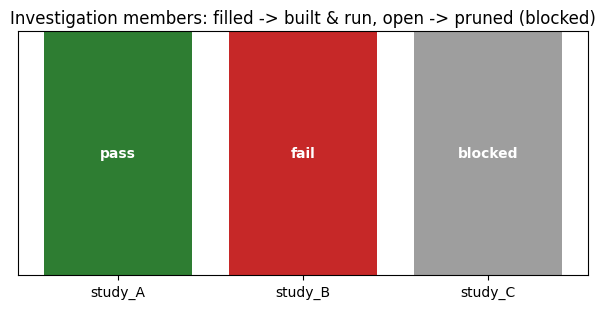

In [10]:
# Visualize the three members: two built (with verdicts), one pruned.
names = ['study_A', 'study_B', 'study_C']
status = {}
for n in names:
    if n in built:
        status[n] = sim.state['investigation'][n]['verdict']
    else:
        status[n] = 'blocked'
cmap = {'pass': '#2e7d32', 'fail': '#c62828', 'blocked': '#9e9e9e'}
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(names, [1, 1, 1], color=[cmap[status[n]] for n in names])
for x, n in enumerate(names):
    ax.text(x, 0.5, status[n], ha='center', va='center', color='white', fontweight='bold')
ax.set_yticks([]); ax.set_ylim(0, 1)
ax.set_title('Investigation members: filled -> built & run, open -> pruned (blocked)')
plt.tight_layout(); plt.show()

## 6. Filling is incremental

You do not have to fill everything at once. `fill_template` binds the sites you give it
and leaves the rest open — the result is *still a template*, ready for the next round of
filling. Groundness is what separates "keep filling" from "ready to run".

In [11]:
partial = fill_template(core, investigation, {'investigation/study_A/model': model(1.5)})
print('after filling A only:')
print('  still open:', sorted(open_sites(partial)))
print('  ground?   ', is_ground_document(partial), '  <- B and C still open')

whole = fill_template(core, partial, {
    'investigation/study_B/model': model(0.5),
    'investigation/study_C/model': model(1.2)})
print('after filling B and C:')
print('  still open:', open_sites(whole))
print('  ground?   ', is_ground_document(whole), '  <- now runnable')

after filling A only:
  still open: [('investigation', 'study_B', 'model'), ('investigation', 'study_C', 'model')]
  ground?    False   <- B and C still open
after filling B and C:
  still open: []
  ground?    True   <- now runnable


## 7. Templates on disk: `*.template.yaml`

A template is authorable as a file. `save_template` writes a document with its sites
intact; `load_template` reads it back to *exactly* the same template (bigraph-schema's
`_sort` round-trip means a site's interface and default survive the file). A **study**
and an **investigation** template are the *same on-disk shape* — a document with sites —
so one loader reads both; the caller picks `template_document` (study) or
`investigation_document` (investigation).

In [12]:
import tempfile, os
from process_bigraph.templates import save_template, load_template

tmpdir = tempfile.mkdtemp()
path = os.path.join(tmpdir, 'growth_study.template.yaml')

save_template(core.access({'study': study_region(threshold=2.0)}), path, core)
print('--- growth_study.template.yaml ---')
print(open(path).read())

reloaded = load_template(path, core)
print('reloaded open sites:', open_sites(reloaded))
doc = template_document(core, reloaded, {'study/model': model(rate=0.5)})
s = Composite({'state': doc}, core=core); s.run(4.0)
print('reloaded template runs -> verdict:', s.state['study']['verdict'])

--- growth_study.template.yaml ---
study:
  level: 1.0
  model:
    _sort:
      _inputs:
        level: float
      _outputs:
        level: float
      _type: link
    _type: site
  report:
    _type: step
    address: local:ReportCard
    config:
      threshold: 2.0
    inputs:
      level:
      - level
    outputs:
      verdict:
      - verdict
    priority: 0.0
  verdict: string

reloaded open sites: [('study', 'model')]
reloaded template runs -> verdict: pass


## 8. Where this goes next

Filling a *model* site is the base case. The same fill/groundness law powers the rest of
the framework:

- **Pull-or-compute (`trigger`).** A cached study result is simply a **filled `results`
  site**: an open results site means the study computes, a filled one means it does not
  and its consumers read the cached handle. `trigger(document, target)` walks a member's
  prerequisites and fills each from a content-addressed artifact if present (**pull**) or
  computes it (**compute**) — the same fill/prune law, on the results axis. This is how
  you rerun one downstream study without rerunning an expensive upstream one (e.g. reuse a
  ParCa fit). See the
  [partial-graph-trigger design](https://github.com/vivarium-collective/process-bigraph/blob/main/docs/superpowers/specs/2026-07-31-partial-graph-trigger-pull-or-compute-design.md).
- **Authoring in the Vivarium Workbench.** On disk in a workspace, a study is a
  `studies/<slug>/study.yaml` (a `composite` + `config` + `inputs`) and an investigation
  is `investigations/<name>/spec.yaml` listing member studies. The Workbench converts
  those specs into exactly the template documents above and runs `trigger` over them.
- **The whole map.** [`doc/architecture.md`](https://github.com/vivarium-collective/process-bigraph/blob/main/doc/architecture.md)
  — one object (a document), one operation (fill), one law (groundness) — and the eight
  invariants everything else follows from.

### Recap

| concept | in code |
|---|---|
| a hole | `{'_type': 'site', '_sort': FACE}` written in place |
| what fits a hole | anything matching the site's `_sort` (face-checked) |
| runnable? | `is_ground_document(doc)` — no required site left open |
| fill a study | `template_document(core, tmpl, {'path/to/site': filler})` |
| fill an investigation | `investigation_document(core, tmpl, bindings, member_depth=...)` |
| gating | fill a member to build it; leave it open to prune it |
| on disk | `*.template.yaml` via `save_template` / `load_template` |